## Heart Failure Prediction: A Comprehensive Data Analysis with Python

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os


In [2]:
os.chdir('C:\\Users\\chaia\\Desktop\\Lorena\\estudio\\Curso_Data\\Pandas\\PANDAS\\data')

Data Loading

In [3]:
heart = pd.read_csv('heart.csv')

Initial Review

In [4]:
heart

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [5]:
heart.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [6]:
heart.tail(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
908,63,M,ASY,140,187,0,LVH,144,Y,4.0,Up,1
909,63,F,ASY,124,197,0,Normal,136,Y,0.0,Flat,1
910,41,M,ATA,120,157,0,Normal,182,N,0.0,Up,0
911,59,M,ASY,164,176,1,LVH,90,N,1.0,Flat,1
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [7]:
heart.shape

(918, 12)

In [8]:
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [9]:
heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Data Cleaning and Treatment

In [10]:
heart.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [11]:
# Removing rows with zero values in 'Cholesterol' column
heart_clean = heart[heart['Cholesterol'] > 0]

In [12]:
heart_clean.shape

(746, 12)

In [12]:
heart_clean.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,746.00,746.00,746.00,746.00,746.00,746.00,746.00
mean,52.88,133.02,244.64,0.17,140.23,0.90,0.48
std,9.51,17.28,59.15,0.37,24.52,1.07,0.50
min,28.00,92.00,85.00,0.00,69.00,-0.10,0.00
25%,46.00,120.00,207.25,0.00,122.00,0.00,0.00
50%,54.00,130.00,237.00,0.00,140.00,0.50,0.00
75%,59.00,140.00,275.00,0.00,160.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [13]:
# Comparing health metrics between healthy and ill patients
comparison = heart_clean.groupby('HeartDisease').mean(numeric_only=True).round(2)

In [14]:
comparison

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
HeartDisease,,,,,,
0,50.17,130.16,238.77,0.11,149.06,0.39
1,55.85,136.15,251.06,0.23,130.55,1.46


## Graphs

Graph1: Heart Disease (Pie Chart)

This chart shows the distribution of healthy vs. ill patients

In [15]:
mask = heart_clean['HeartDisease'].value_counts()

In [16]:
mask

HeartDisease
0    390
1    356
Name: count, dtype: int64

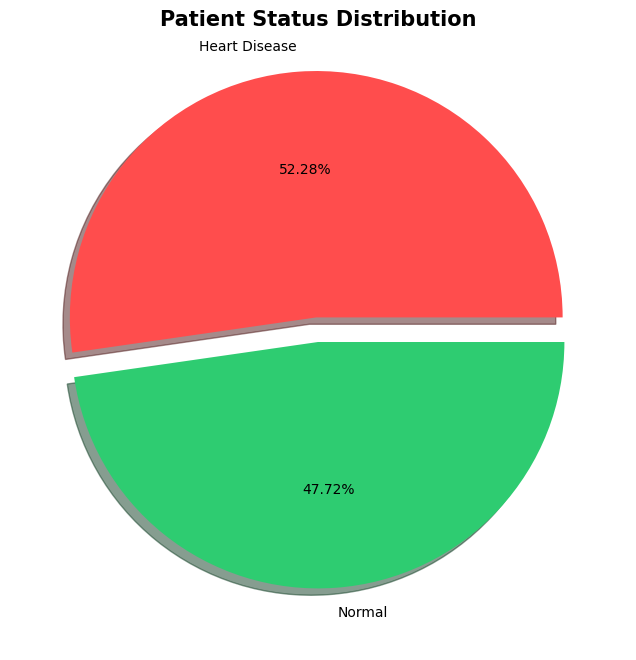

In [18]:
plt.figure(figsize=(8, 8))
plt.pie(mask, labels=['Heart Disease', 'Normal'], autopct='%1.2f%%', explode=(0.1, 0), shadow=True, colors=["#ff4d4d","#2ecc71"])

plt.title('Patient Status Distribution', fontsize=15, fontweight='bold')
plt.show()

This chart shows a nearly balanced dataset, with 52.28% of patients diagnosed with heart disease and 47.72% remaining healthy.






## Graph2: Age Distribution by Health Status (Histogram)

This chart helps us understand the age range of the patients


In [19]:
#Filtering data for healthy and ill patients (Age)
ill_patients = heart_clean[heart_clean['HeartDisease'] == 1]['Age']
healthy_patients = heart_clean[heart_clean['HeartDisease'] == 0]['Age']

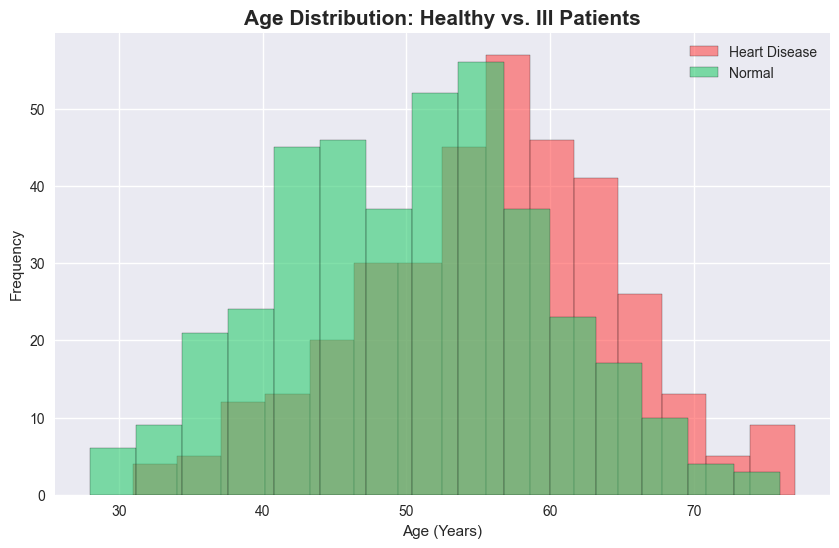

In [21]:

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 6))

plt.hist(ill_patients, label='Heart Disease', color='#ff4d4d', edgecolor='black', alpha=0.6, bins=15)
plt.hist(healthy_patients, label='Normal', color='#2ecc71', edgecolor='black', alpha=0.6, bins=15)

plt.title('Age Distribution: Healthy vs. Ill Patients', fontsize=15, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.legend()

plt.show()

The histogram reveals that heart disease cases (red) tend to increase and concentrate in patients aged between 50 and 65 years.

## Graph3: Chest Pain Type vs Heart Disease (Bar Chart)

This chart compares the number of healthy vs. ill patients for each chest pain category.

In [22]:
#Summarizes the data by counting patients in each chest pain category and reorganizing them into a table format for the grouped bar chart
pain_stats = heart_clean.groupby(['ChestPainType', 'HeartDisease']).size().unstack(fill_value=0)

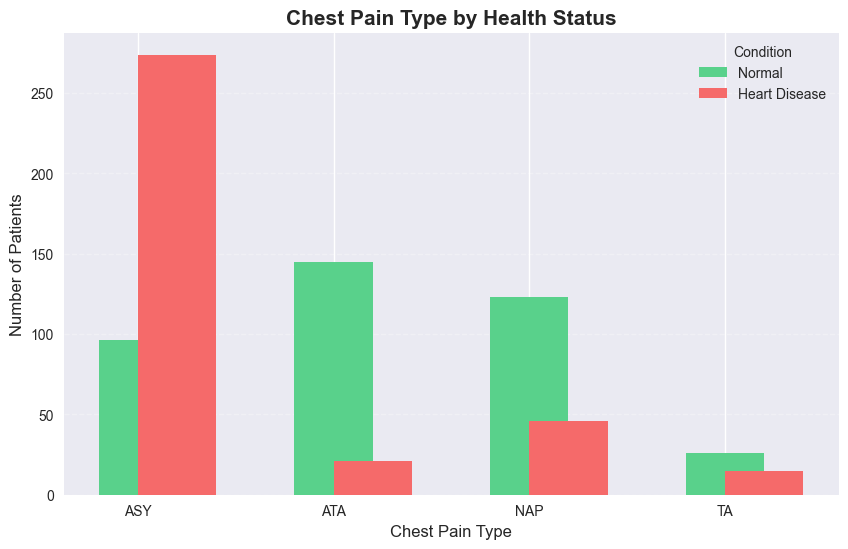

In [28]:
plt.figure(figsize=(10, 6))

plt.bar(x = pain_stats.index, height = pain_stats[0], width=0.4, label='Normal', align='center', color="#59d18b")
plt.bar(x = pain_stats.index, height = pain_stats[1], width=0.4, label='Heart Disease', align='edge', color="#f56a6a")

plt.title('Chest Pain Type by Health Status', fontsize=15, fontweight='bold')
plt.xlabel('Chest Pain Type', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

plt.legend(title='Condition')
plt.grid(axis='y', linestyle='--', alpha=0.3)

#plt.show()

Asymptomatic (ASY) chest pain is identified as the most critical symptom, showing a significantly higher frequency of heart disease compared to other pain types

## Graph4: Cholesterol Trends: Men vs. Women (Line Chart)

This chart compares the cholesterol trends between Men and Women across different age ranges.

In [24]:
# Create age groups and calculate average cholesterol per age group and sex
heart_clean['AgeGroup'] = (heart_clean['Age'] // 5) * 5
gender_trend = heart_clean.groupby(['AgeGroup', 'Sex'])['Cholesterol'].mean().unstack()

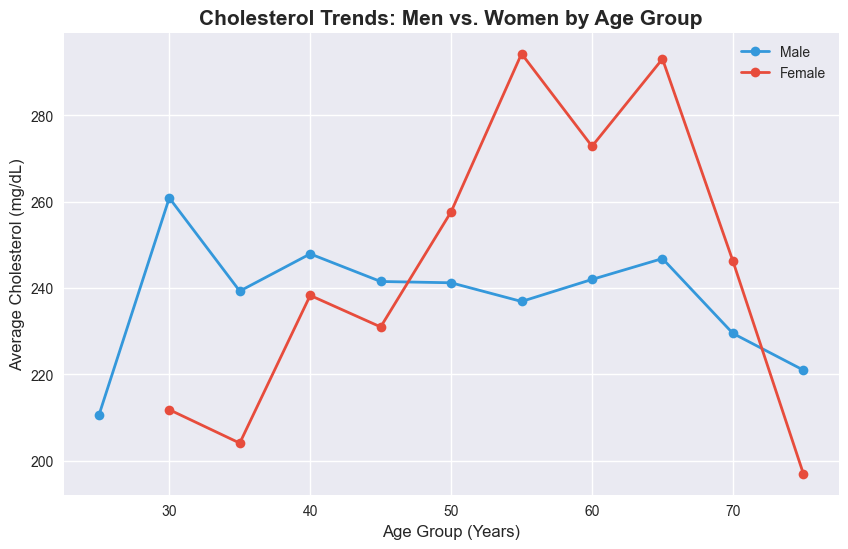

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(gender_trend.index, gender_trend['M'], label='Male', color='#3498db', marker='o', linewidth=2)
plt.plot(gender_trend.index, gender_trend['F'], label='Female', color='#e74c3c', marker='o', linewidth=2)

plt.title('Cholesterol Trends: Men vs. Women by Age Group', fontsize=15, fontweight='bold')
plt.xlabel('Age Group (Years)', fontsize=12)
plt.ylabel('Average Cholesterol (mg/dL)', fontsize=12)

plt.legend()

plt.show()

Average cholesterol levels fluctuate by age, with women showing sharper increases in specific age groups compared to the more stable trend in men.

## Graph5: Correlation Heatmap

This matrix shows the correlation coefficients between numerical variables.
It helps identify which factors are most closely related to heart disease.

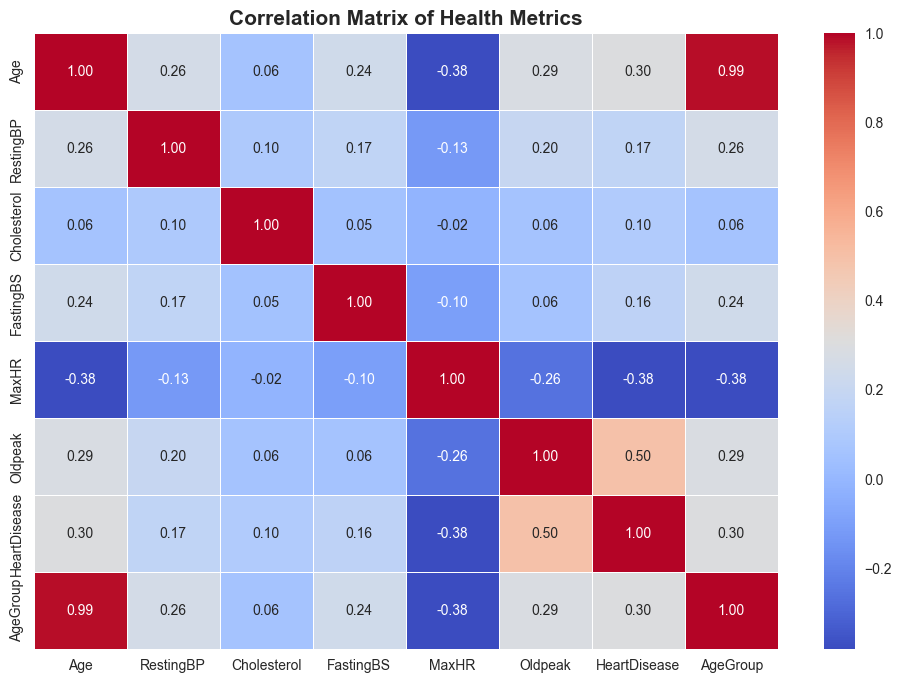

In [29]:
plt.figure(figsize=(12, 8))

# Select only numerical columns for correlation
numerical_cols = heart_clean.select_dtypes(include=['number'])
correlation_matrix = numerical_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Health Metrics', fontsize=15, fontweight='bold')

plt.show()

The heatmap indicates that 'Oldpeak' has the strongest positive correlation with heart disease, while 'MaxHR' shows a negative relationship with the condition.

*Oldpeak refers to the ST depression induced by exercise relative to rest.